In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df = pd.read_csv('cheating_detection_dataset_6.csv')
df
df.info()
df.archetype.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   participant_id               5010 non-null   int64  
 1   competition_id               5010 non-null   int64  
 2   total_submissions            5010 non-null   int64  
 3   active_days                  5010 non-null   int64  
 4   submissions_per_day          5010 non-null   float64
 5   submission_avg_initial_days  5010 non-null   float64
 6   avg_submissions_mid          5010 non-null   float64
 7   submissions_end              5010 non-null   int64  
 8   median_score                 5010 non-null   float64
 9   top_score                    5010 non-null   float64
 10  lowest_score                 5010 non-null   float64
 11  gap_median_top               5010 non-null   float64
 12  gap_lowest_top               5010 non-null   float64
 13  peak_submissions_p

array(['hardworker', 'benchmark_tweaker', 'daily_sprinter',
       'consistent_late_breakthrough', 'low_interest_quitter',
       'consistent_ai_leap', 'ai_dump_sincere_start',
       'late_joiner_dangerous', 'pure_ai_quick_dump'], dtype=object)

In [9]:
df.describe()

,participant_id,competition_id,total_submissions,active_days,submissions_per_day,submission_avg_initial_days,avg_submissions_mid,submissions_end,median_score,top_score,...,time_to_best_score_hours,submissions_pre_jump,submissions_post_jump,leap_size,post_jump_score_repetition,quiz_participation,final_rank,rank_to_submissions,rank_to_quiz_participation,description_rate
count,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,...,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,2505.500000,81.760878,17.050100,5.986427,2.943809,1.274584,1.850566,2.058084,1.125471,0.639125,...,134.999983,5.501397,11.548703,0.723111,0.273213,5.749701,17.302395,2.129755,2.865460,0.731921
std,1446.406755,46.213924,10.231152,2.737650,1.428400,1.081569,1.455606,2.490313,0.480451,0.327723,...,79.201862,4.800065,9.899864,0.582813,0.331023,1.786136,10.803189,3.674015,2.402233,0.153076
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.383584,0.300000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.015873,0.100000,0.000000
25%,1253.250000,42.000000,9.000000,4.000000,2.000000,0.333333,0.666667,0.000000,0.650485,0.440747,...,52.319197,2.000000,4.000000,0.242395,0.000000,5.000000,8.000000,0.457143,1.250000,0.654000
50%,2505.500000,83.000000,16.000000,6.000000,2.625000,1.000000,1.666667,1.000000,1.121701,0.542338,...,163.593138,4.000000,9.000000,0.488358,0.026930,6.000000,16.000000,1.000000,2.400000,0.750000
75%,3757.750000,122.000000,23.000000,8.000000,3.500000,2.000000,2.666667,3.000000,1.488934,0.719577,...,202.215623,7.000000,17.000000,1.242790,0.579765,7.000000,25.000000,2.066667,3.833333,0.828000
max,5010.000000,160.000000,75.000000,10.000000,10.000000,6.000000,8.666667,10.000000,2.554217,2.547187,...,239.468945,35.000000,66.000000,2.226358,1.000000,10.000000,46.000000,45.000000,39.000000,1.000000


In [10]:
df = df.drop(columns = ['participant_id','competition_id'])
df


,total_submissions,active_days,submissions_per_day,submission_avg_initial_days,avg_submissions_mid,submissions_end,median_score,top_score,lowest_score,gap_median_top,...,submissions_pre_jump,submissions_post_jump,leap_size,post_jump_score_repetition,quiz_participation,final_rank,rank_to_submissions,rank_to_quiz_participation,description_rate,archetype
0,4,3,1.333333,0.000000,0.333333,0,1.746106,0.816072,2.261419,0.930035,...,3,1,1.426924,0.000000,5,15,3.750000,2.500000,0.500,hardworker
1,21,8,2.625000,1.333333,2.000000,2,1.397039,0.505444,2.316454,0.891595,...,15,6,0.317983,0.590711,5,7,0.333333,1.166667,0.762,benchmark_tweaker
2,26,8,3.250000,0.333333,3.333333,9,1.148055,0.650068,2.475498,0.497987,...,4,22,1.308404,0.000000,6,13,0.500000,1.857143,0.808,hardworker
3,12,6,2.000000,1.333333,1.333333,0,1.218825,1.005571,2.417817,0.213254,...,1,11,0.760568,0.000000,6,18,1.500000,2.571429,0.833,hardworker
4,29,10,2.900000,2.666667,3.666667,4,0.494276,0.351093,1.266685,0.143183,...,3,26,0.270533,0.000000,8,2,0.068966,0.222222,0.828,daily_sprinter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5005,29,7,4.142857,2.333333,4.000000,10,1.755678,0.395010,2.125157,1.360668,...,20,9,1.231086,0.566223,6,6,0.206897,0.857143,0.690,ai_dump_sincere_start
5006,29,10,2.900000,2.666667,3.000000,2,0.582251,0.409273,1.065152,0.172978,...,19,10,0.219579,0.531388,7,7,0.241379,0.875000,0.655,daily_sprinter
5007,9,6,1.500000,0.666667,0.000000,2,1.055534,0.566114,2.038870,0.489421,...,1,8,0.773652,0.000000,5,24,2.666667,4.000000,0.889,hardworker
5008,24,9,2.666667,3.666667,3.000000,1,1.275355,0.644566,1.999642,0.630789,...,7,17,0.217512,0.000000,6,28,1.166667,4.000000,0.667,benchmark_tweaker


In [11]:
print(df.duplicated().sum())
df = df[df.duplicated() == False]
print(df.duplicated().sum())
df.head()
df.shape

0
0


(5010, 30)

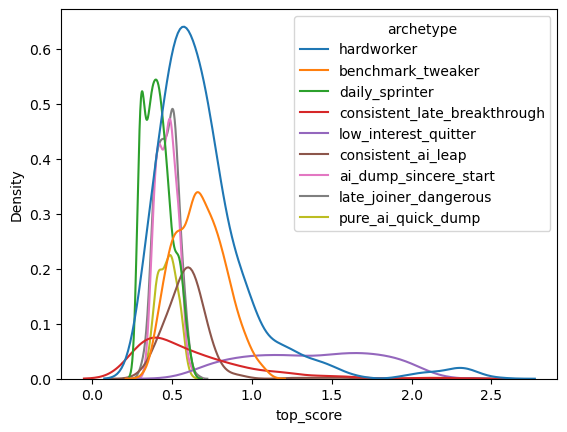

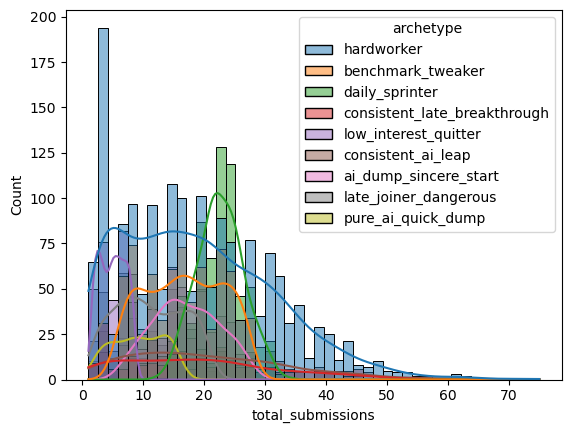

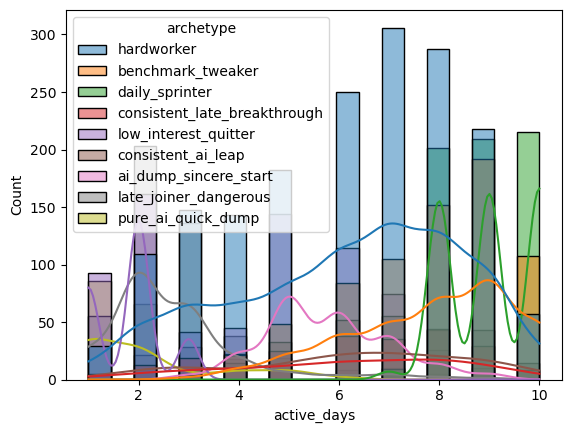

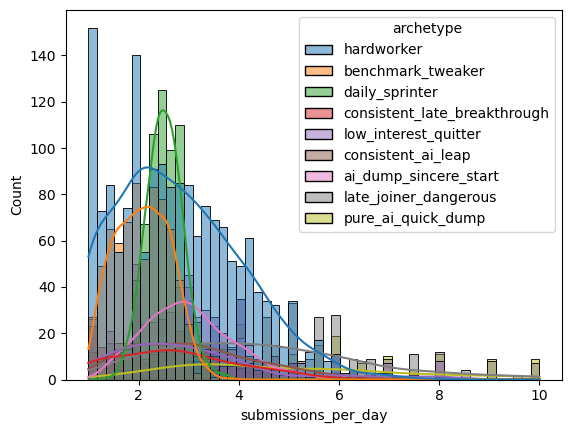

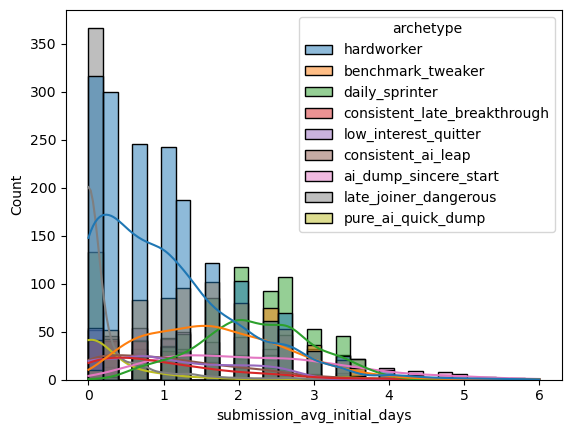

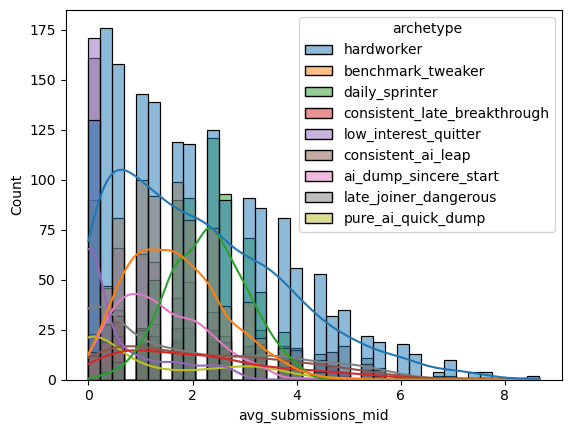

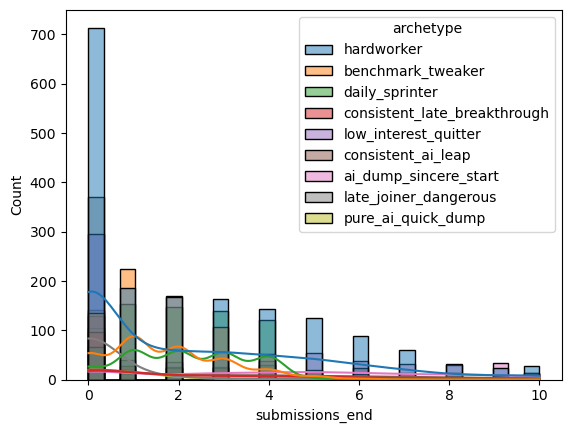

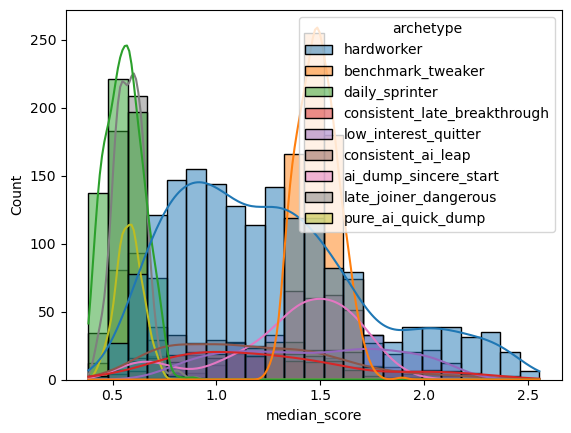

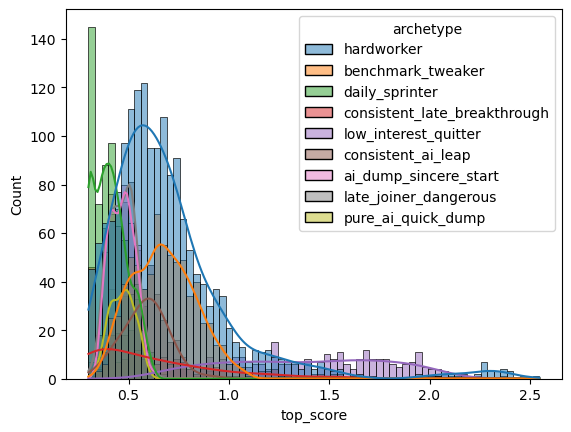

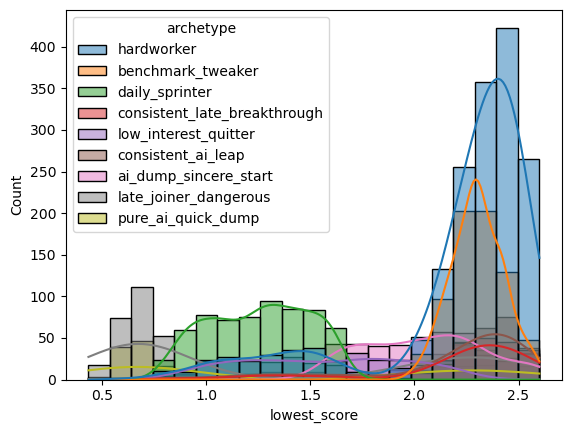

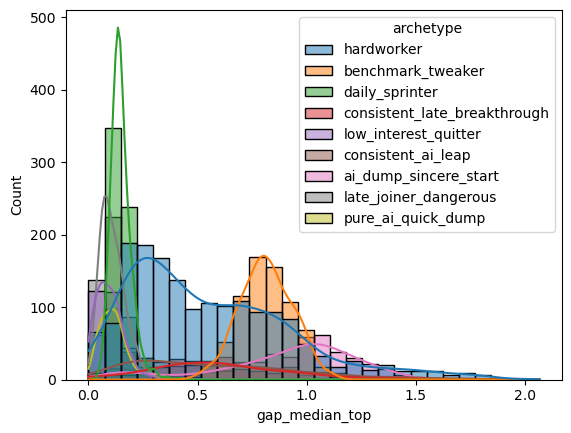

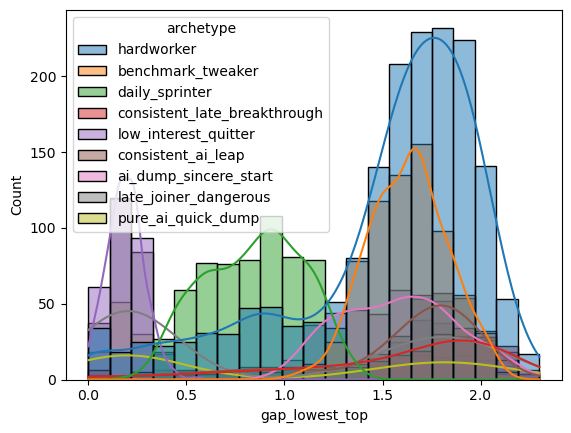

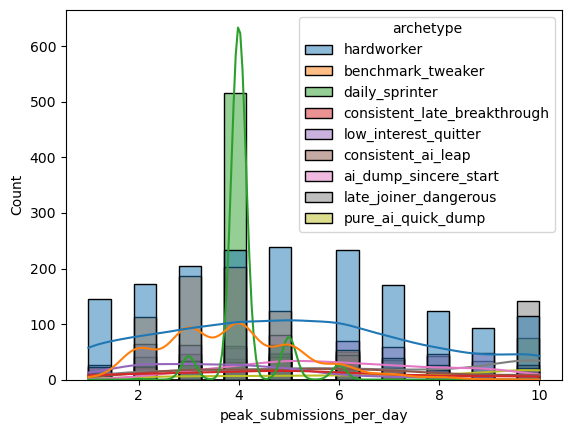

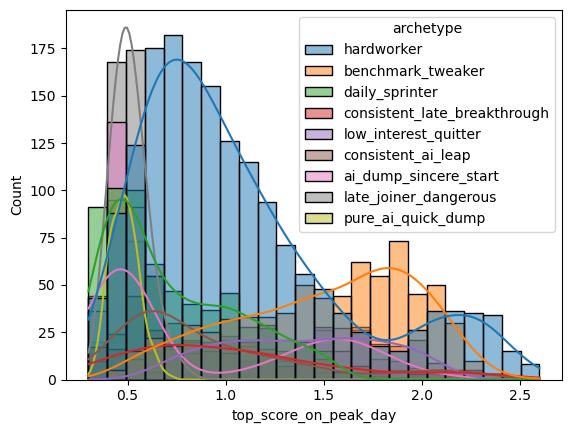

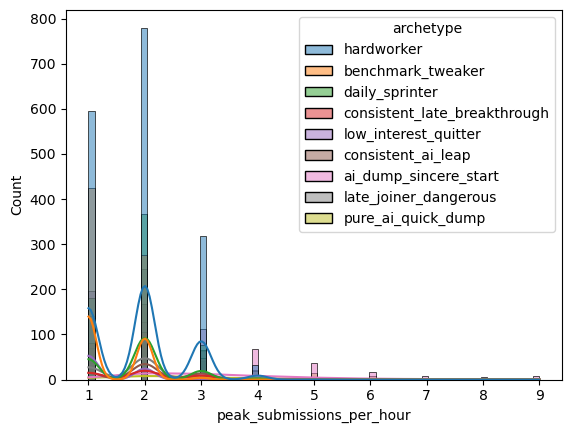

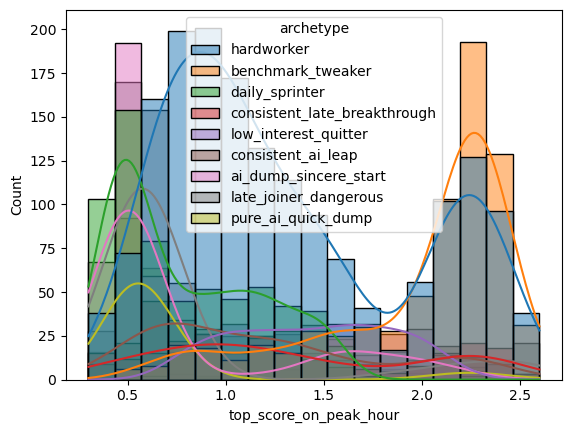

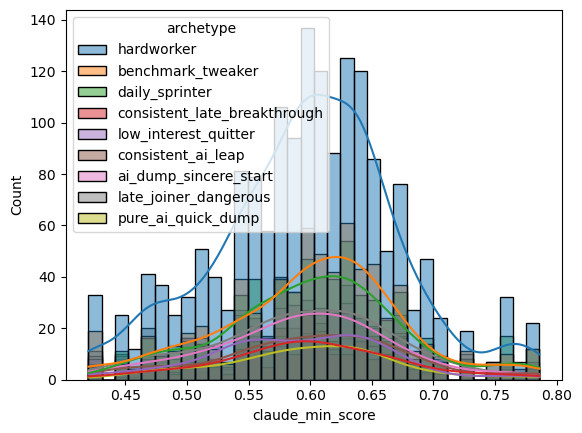

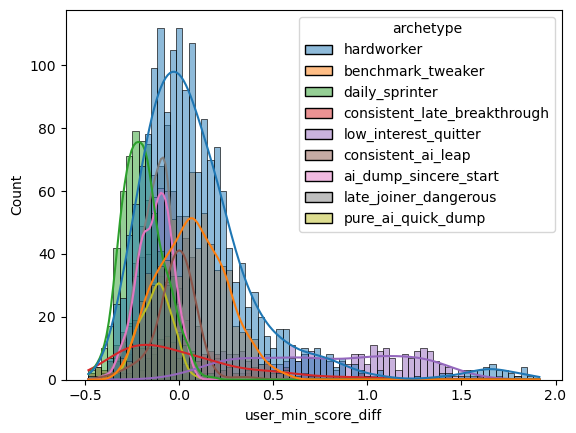

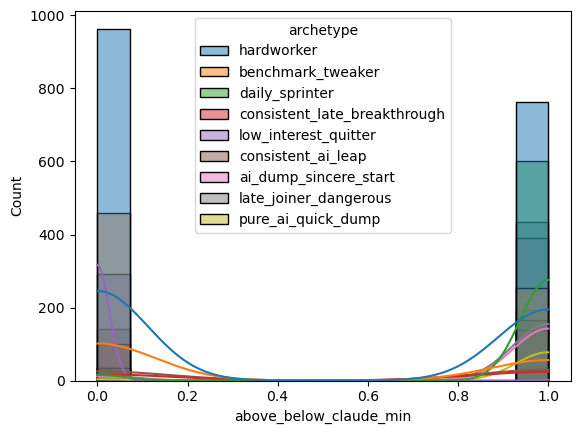

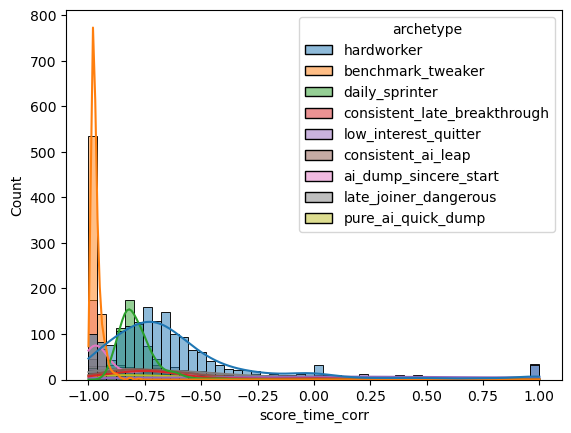

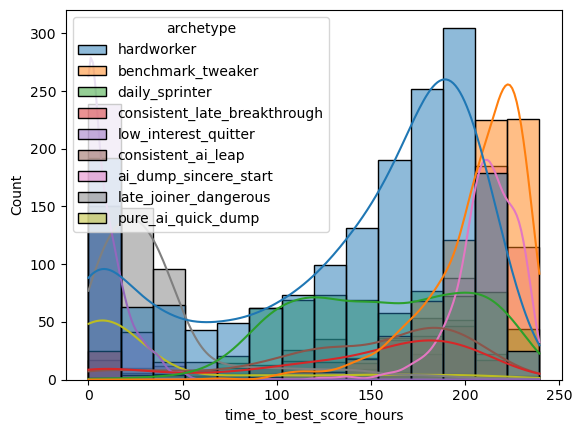

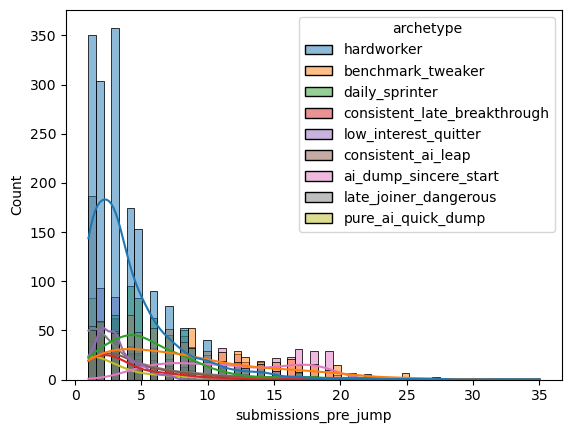

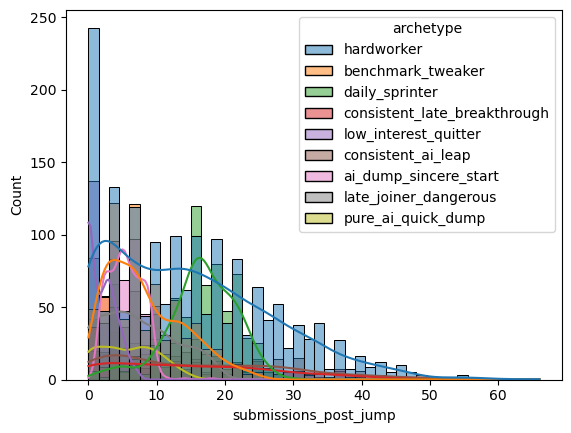

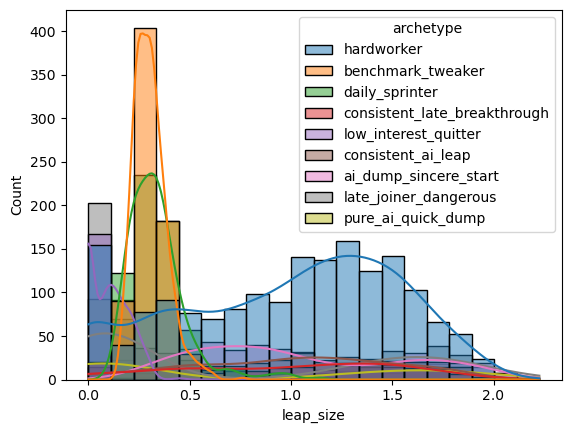

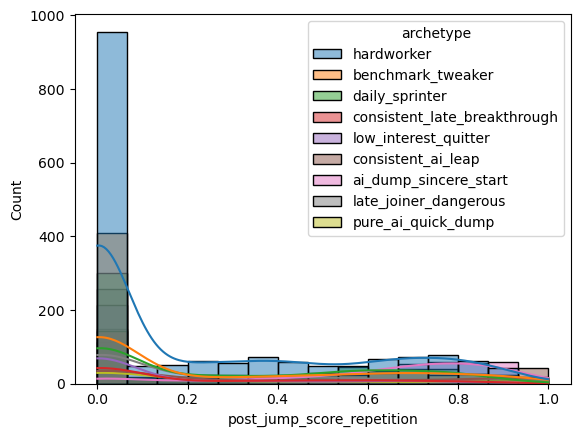

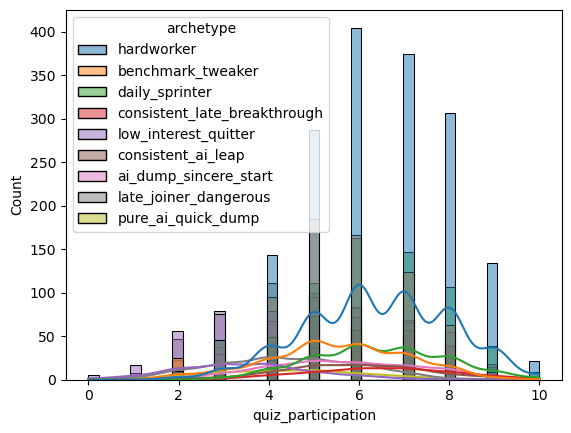

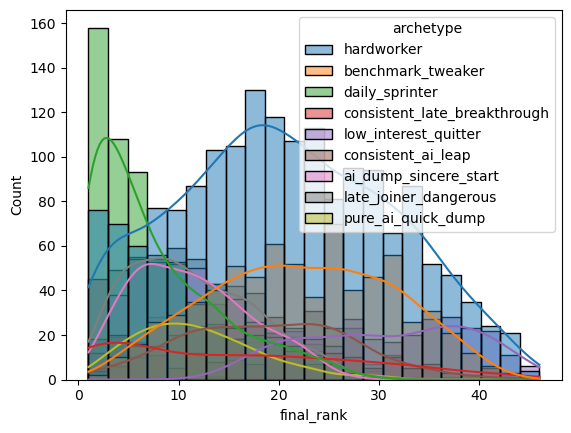

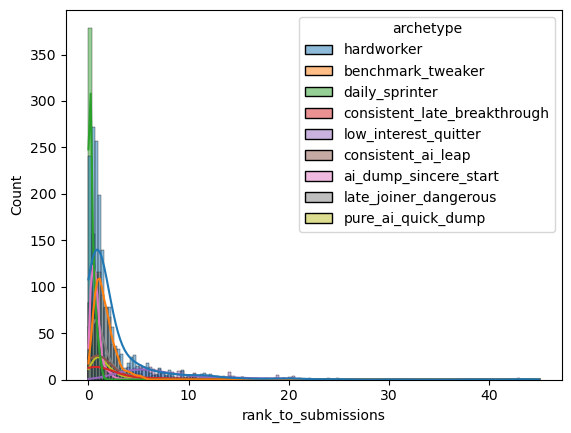

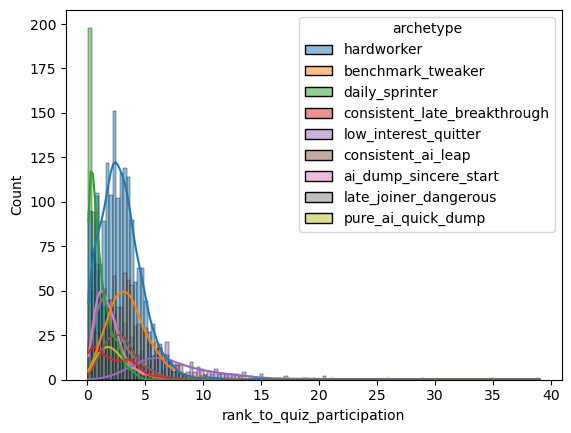

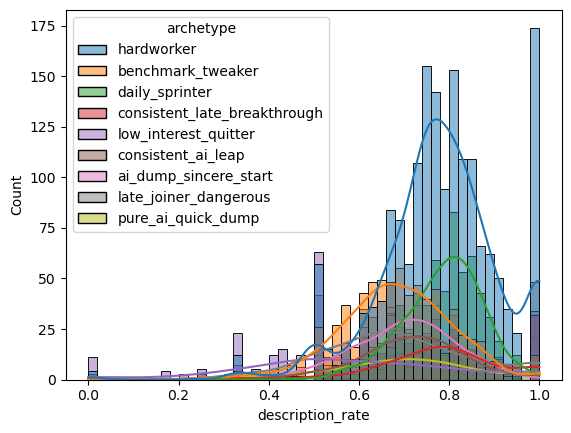

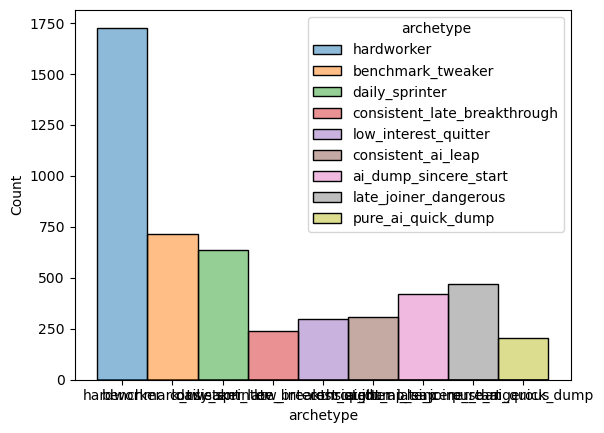

KeyError: 'cheated'

In [ ]:
sns.kdeplot(data = df, x= 'top_score', hue = 'archetype')
plt.show()
plt.close()
for i in df.columns:
    sns.histplot(data = df, x= i, hue = 'archetype', kde=True)
    plt.show()
    plt.close()

# display(df2['BMI'].describe())
# df['BMI'].describe()
cat_columns = ['active_days', 'peak_submissions_per_hour', 'peak_submissions_per_day', 'quiz_participation','final_rank', 'archetype']
d = {i:np.sort(df[i].unique()) for i in cat_columns}
d

In [ ]:
# cheated = df['cheated'].sum()
# cat_columns = ['active_days', 'peak_submissions_per_hour', 'peak_submissions_per_day', 'quiz_participation','final_rank']
# for i in cat_columns:
#     if i == 'cheated':
#         continue
#     print(i)
#     for j in d[i]:
#         a = df[df[i] == j]
#         b = a['cheated'].sum()
        
#         print(f"       {j} :\n       Probability of cheating = {(b*100)/(a.shape[0])}       [[TD:{a.shape[0]} '+' :{b}]]\n       overall '+'ve contribution : {(b*100)/(cheated)}")

active_days
       1 :
       Probability of cheating = 53.30882352941177       [[TD:272 '+' :145]]
       overall '+'ve contribution : 8.950617283950617
       2 :
       Probability of cheating = 50.610820244328096       [[TD:573 '+' :290]]
       overall '+'ve contribution : 17.901234567901234
       3 :
       Probability of cheating = 46.42857142857143       [[TD:392 '+' :182]]
       overall '+'ve contribution : 11.234567901234568
       4 :
       Probability of cheating = 39.20265780730897       [[TD:301 '+' :118]]
       overall '+'ve contribution : 7.283950617283951
       5 :
       Probability of cheating = 48.922413793103445       [[TD:464 '+' :227]]
       overall '+'ve contribution : 14.012345679012345
       6 :
       Probability of cheating = 37.023593466424686       [[TD:551 '+' :204]]
       overall '+'ve contribution : 12.592592592592593
       7 :
       Probability of cheating = 29.124579124579125       [[TD:594 '+' :173]]
       overall '+'ve contribution : 10.6

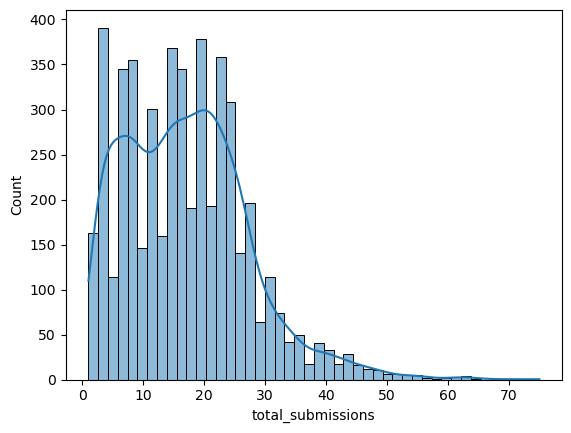

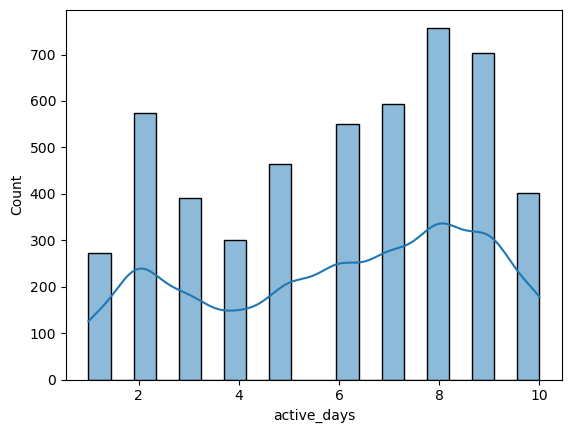

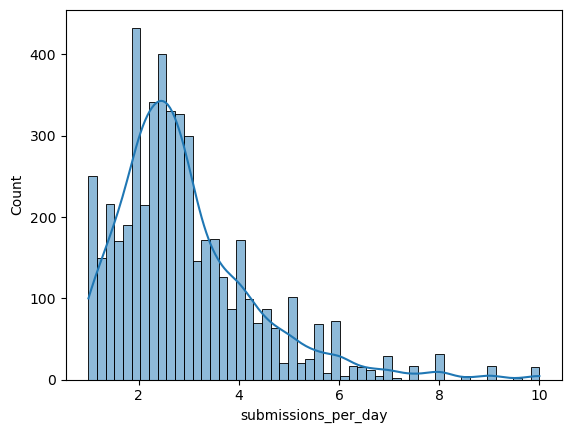

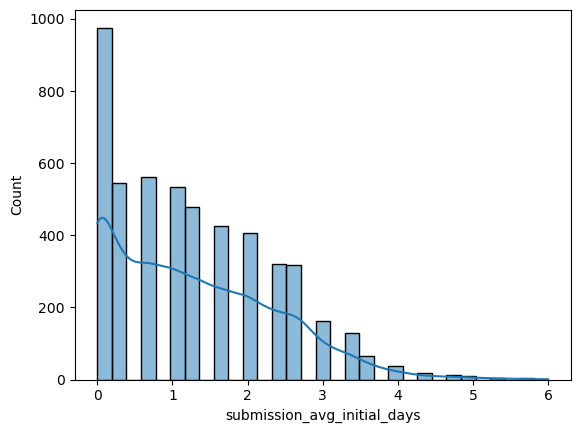

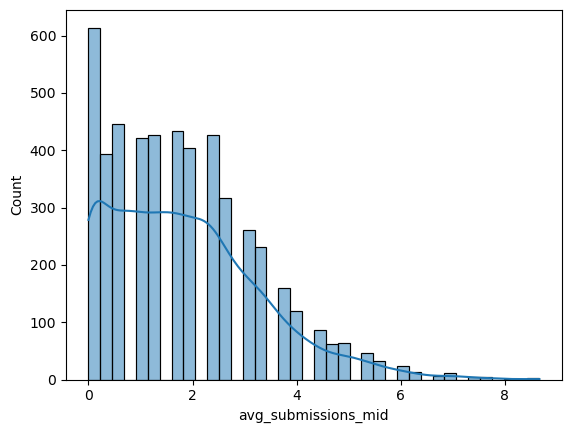

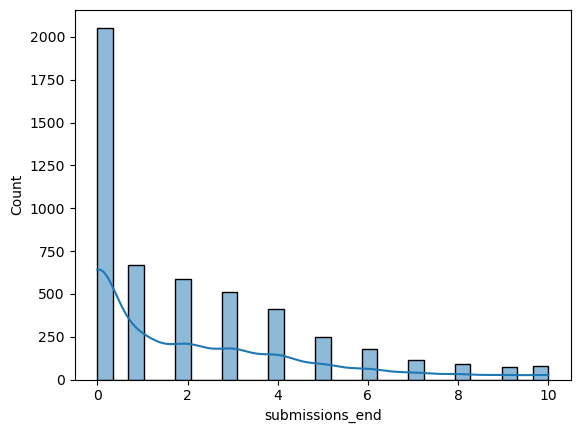

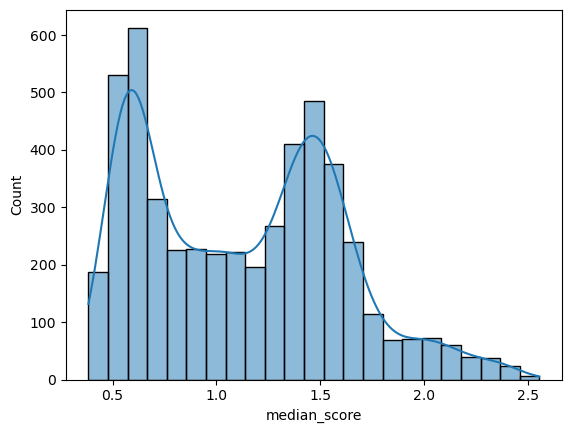

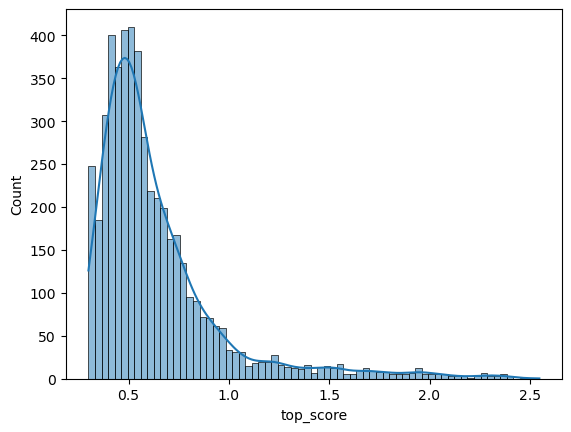

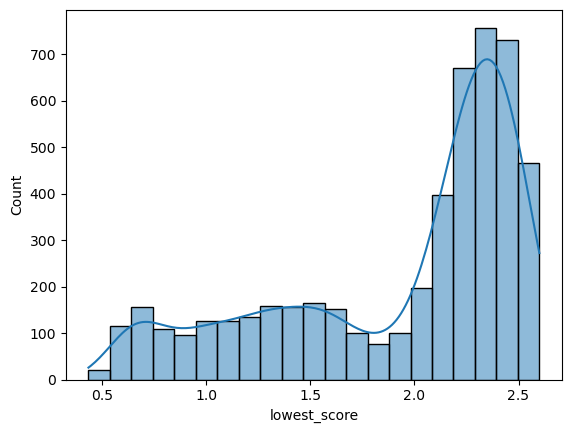

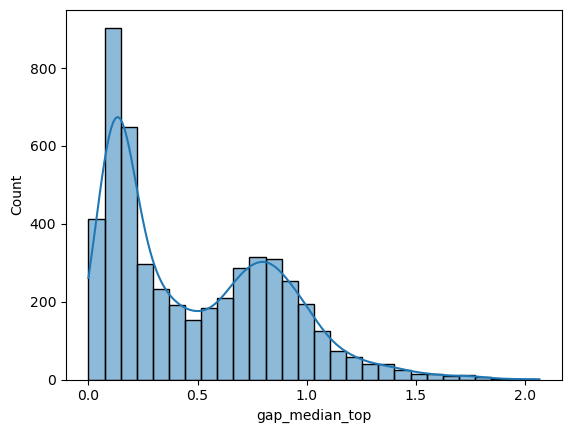

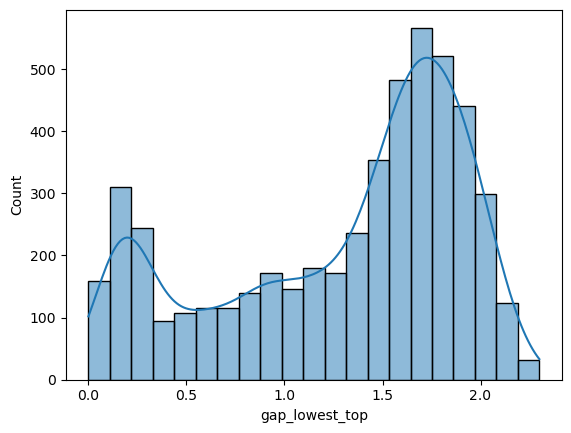

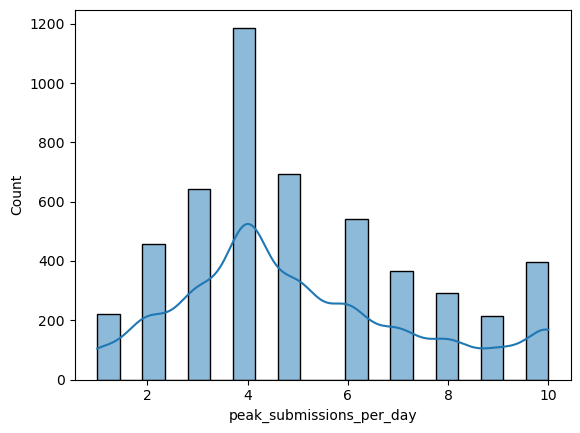

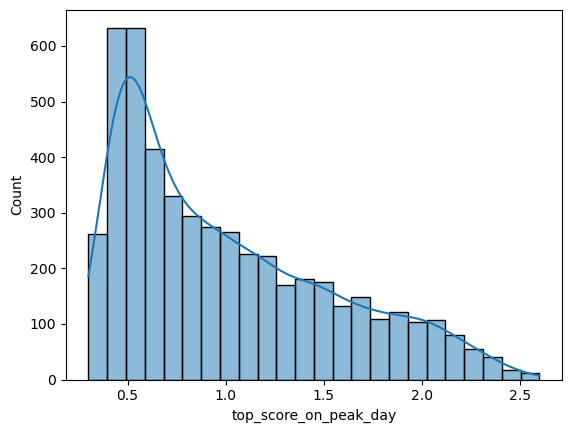

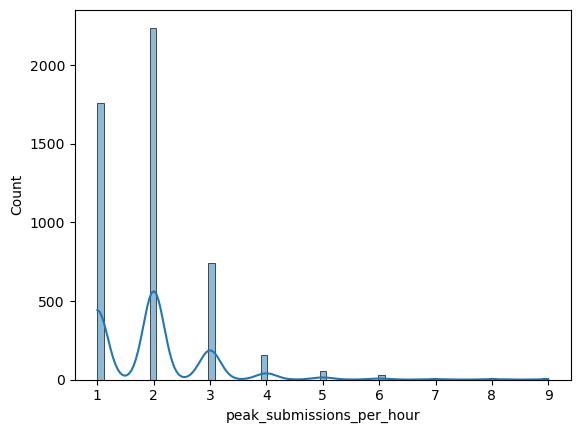

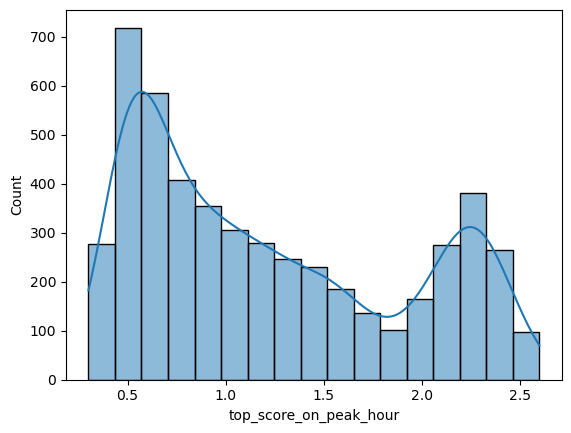

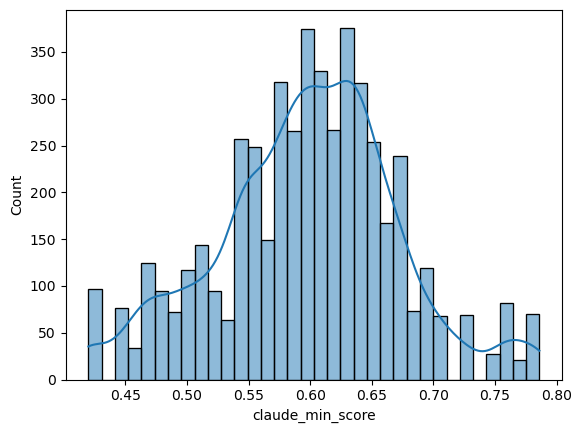

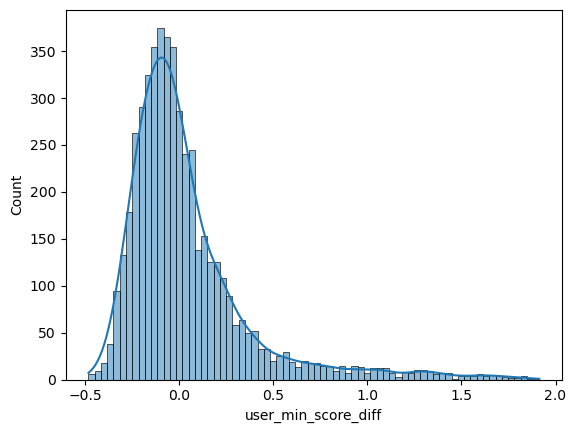

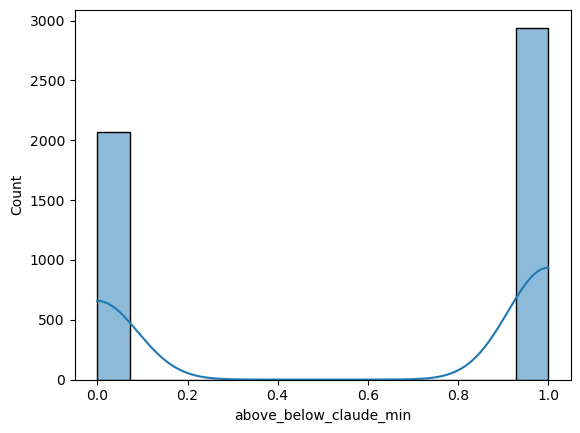

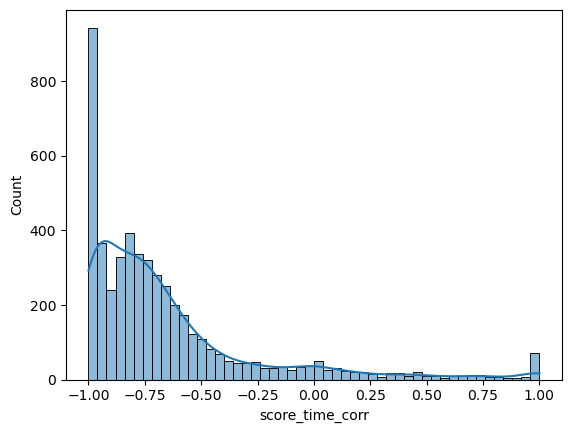

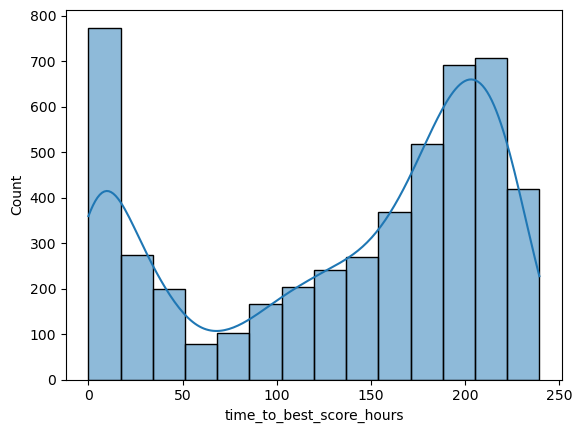

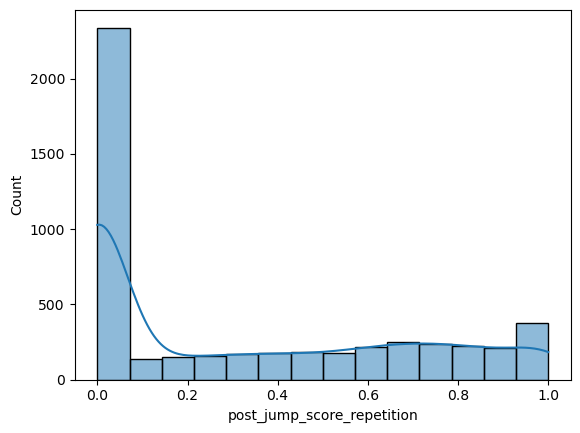

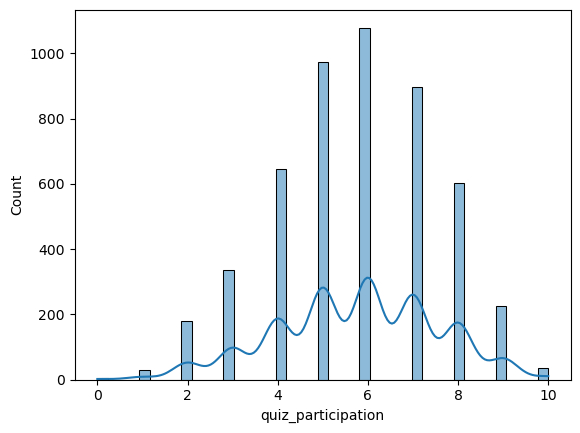

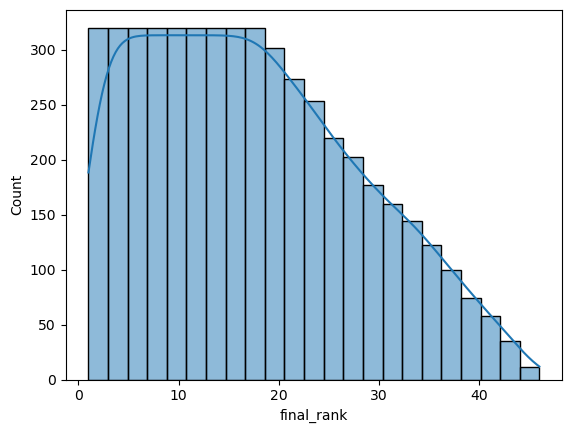

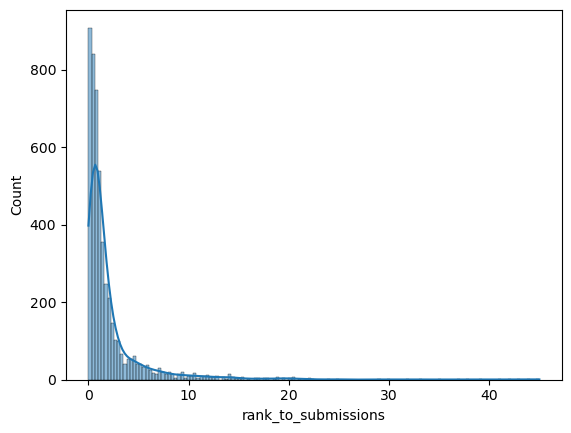

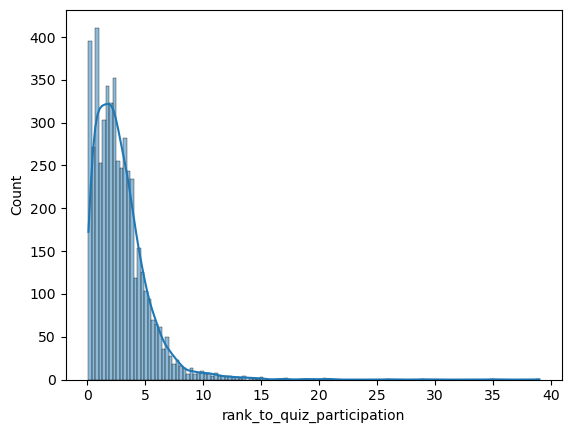

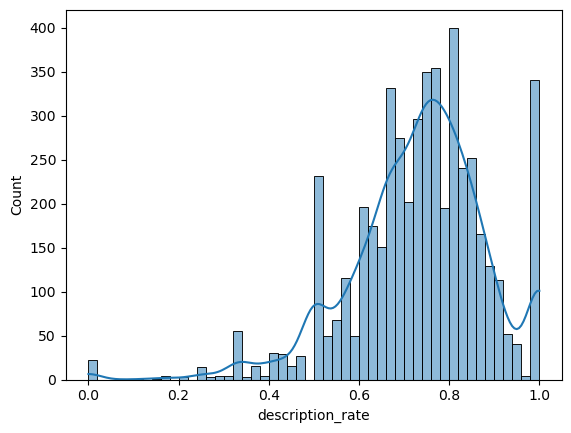

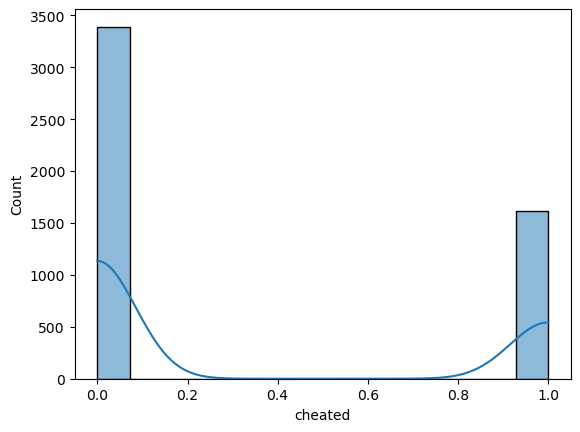

In [ ]:
for i in df.columns:
    sns.histplot(data = df, x= i, kde=True)
    plt.show()
    plt.close()